In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import string

In [2]:
data = pd.read_csv("DATA/spam.csv", encoding='latin-1')

In [3]:
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [4]:
data = data[['v1', 'v2']].rename(columns={'v1':'label', 'v2':'message'})

In [5]:
data

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


<Axes: xlabel='label'>

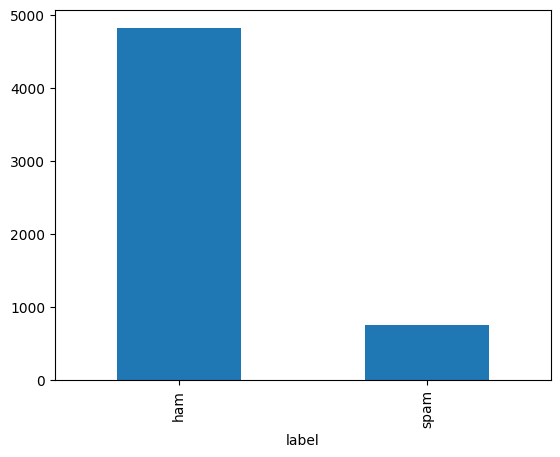

In [6]:
data['label'].value_counts().plot(kind='bar')

In [7]:
data.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
data['message'] = data['message'].str.lower()

In [9]:
data

,label,message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,this is the 2nd time we have tried 2 contact u...
5568,ham,will ì_ b going to esplanade fr home?
5569,ham,"pity, * was in mood for that. so...any other s..."
5570,ham,the guy did some bitching but i acted like i'd...


In [10]:
data['word_count'] = data['message'].str.split(' ').apply(len)
data['letter_count'] = data['message'].apply(lambda x: re.sub(r'[^\w]', '', x)).apply(len)

In [11]:
data

,label,message,word_count,letter_count
0,ham,"go until jurong point, crazy.. available only ...",20,83
1,ham,ok lar... joking wif u oni...,6,18
2,spam,free entry in 2 a wkly comp to win fa cup fina...,28,122
3,ham,u dun say so early hor... u c already then say...,11,33
4,ham,"nah i don't think he goes to usf, he lives aro...",13,47
...,...,...,...,...
5567,spam,this is the 2nd time we have tried 2 contact u...,30,123
5568,ham,will ì_ b going to esplanade fr home?,8,29
5569,ham,"pity, * was in mood for that. so...any other s...",10,41
5570,ham,the guy did some bitching but i acted like i'd...,26,99


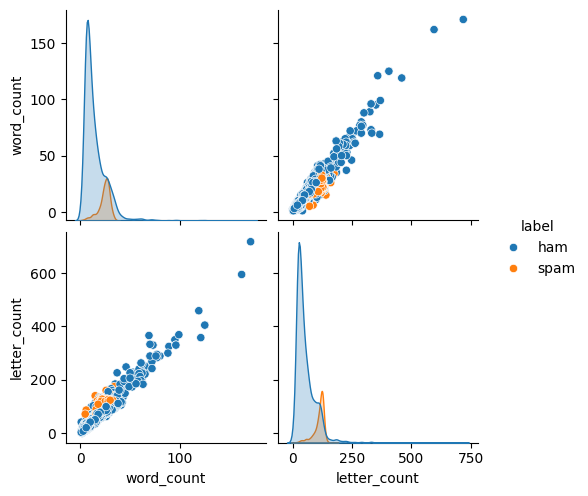

In [12]:
sns.pairplot(data, hue='label')

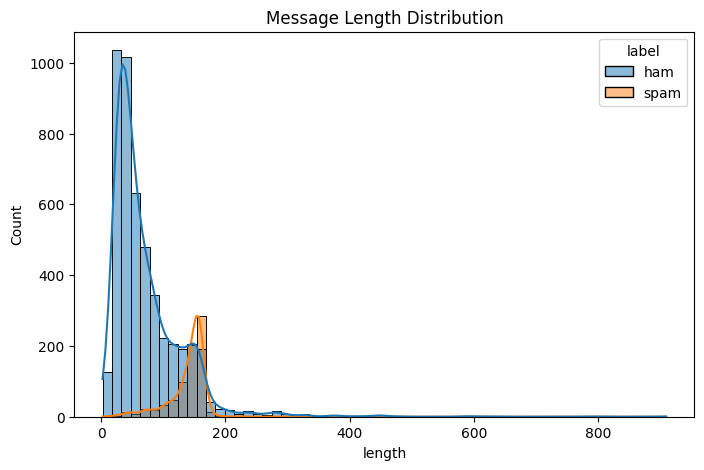

In [13]:
data['length'] = data['message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=data, x='length', hue='label', bins=60, kde=True)
plt.title("Message Length Distribution")
plt.show()

In [14]:
data

,label,message,word_count,letter_count,length
0,ham,"go until jurong point, crazy.. available only ...",20,83,111
1,ham,ok lar... joking wif u oni...,6,18,29
2,spam,free entry in 2 a wkly comp to win fa cup fina...,28,122,155
3,ham,u dun say so early hor... u c already then say...,11,33,49
4,ham,"nah i don't think he goes to usf, he lives aro...",13,47,61
...,...,...,...,...,...
5567,spam,this is the 2nd time we have tried 2 contact u...,30,123,161
5568,ham,will ì_ b going to esplanade fr home?,8,29,37
5569,ham,"pity, * was in mood for that. so...any other s...",10,41,57
5570,ham,the guy did some bitching but i acted like i'd...,26,99,125


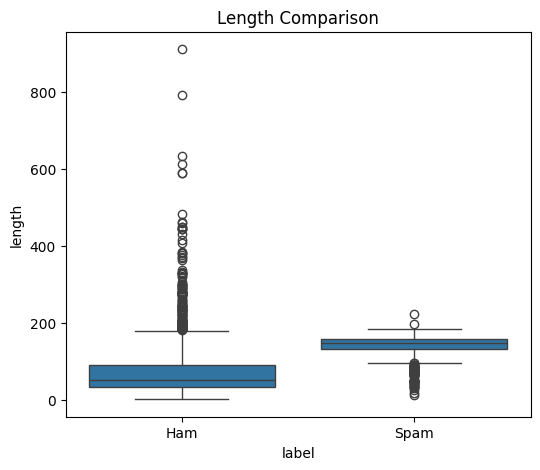

In [15]:
plt.figure(figsize=(6,5))
sns.boxplot(x='label', y='length', data=data)
plt.xticks([0,1], ['Ham','Spam'])
plt.title("Length Comparison")
plt.show()

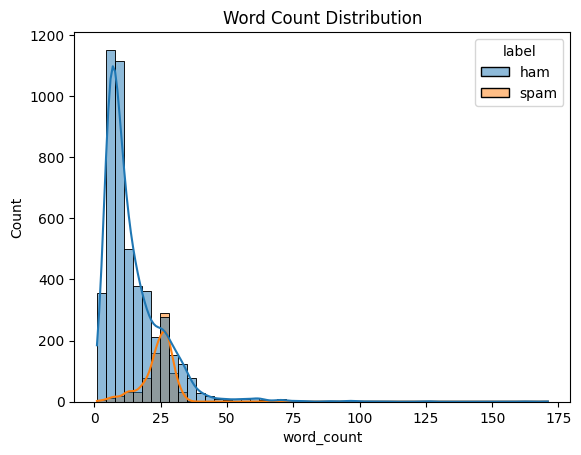

In [16]:
data['word_count'] = data['message'].apply(lambda x: len(x.split()))

sns.histplot(data=data, x='word_count', hue='label', bins=50, kde=True)
plt.title("Word Count Distribution")
plt.show()

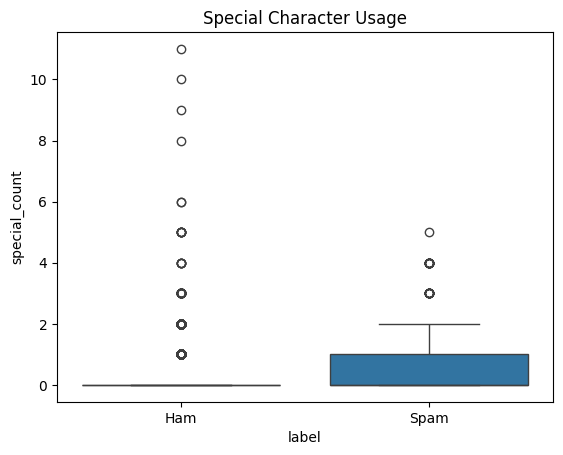

In [17]:
data['special_count'] = data['message'].apply(
    lambda x: len(re.findall(r'[!$%]', x))
)

sns.boxplot(x='label', y='special_count', data=data)
plt.xticks([0,1], ['Ham','Spam'])
plt.title("Special Character Usage")
plt.show()

In [18]:
import joblib
import pickle

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import keras_tuner as kt

In [19]:
le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])

In [20]:
data

,label,message,word_count,letter_count,length,special_count
0,0,"go until jurong point, crazy.. available only ...",20,83,111,0
1,0,ok lar... joking wif u oni...,6,18,29,0
2,1,free entry in 2 a wkly comp to win fa cup fina...,28,122,155,0
3,0,u dun say so early hor... u c already then say...,11,33,49,0
4,0,"nah i don't think he goes to usf, he lives aro...",13,47,61,0
...,...,...,...,...,...,...
5567,1,this is the 2nd time we have tried 2 contact u...,30,123,161,1
5568,0,will ì_ b going to esplanade fr home?,8,29,37,0
5569,0,"pity, * was in mood for that. so...any other s...",10,41,57,0
5570,0,the guy did some bitching but i acted like i'd...,26,99,125,0


In [21]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_series(text_series):
    def clean_text(text):
        text = text.lower()
        text = re.sub(r'\d+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        tokens = text.split()
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
        return " ".join(tokens)
    
    return text_series.apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    data['message'],
    data['label'],
    test_size=0.2,
    stratify=data['label'],
    random_state=42
)

y_train = np.array(y_train).astype('int32')
y_test = np.array(y_test).astype('int32')

In [23]:
ml_models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "NaiveBayes": MultinomialNB(),
    "LinearSVM": LinearSVC()
}

ml_results = {}
best_ml_models = {}

for name, model in ml_models.items():
    
    pipeline = Pipeline([
        ('cleaning', FunctionTransformer(clean_series)),
        ('tfidf', TfidfVectorizer()),
        ('clf', model)
    ])
    
    param_grid = {
        'tfidf__ngram_range': [(1,1),(1,2)]
    }
    
    if name == "Logistic":
        param_grid['clf__C'] = [0.1,1,10]
    if name == "NaiveBayes":
        param_grid['clf__alpha'] = [0.1,1]
    if name == "LinearSVM":
        param_grid['clf__C'] = [0.1,1,10]
    
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_ml_models[name] = best_model
    
    y_pred = best_model.predict(X_test)
    
    ml_results[name] = f1_score(y_test, y_pred)

best_ml_name = max(ml_results, key=ml_results.get)
best_ml_model = best_ml_models[best_ml_name]
best_ml_f1 = ml_results[best_ml_name]

print("Best ML:", best_ml_name, best_ml_f1)

Best ML: LinearSVM 0.9347079037800687


In [24]:
X_train_clean = clean_series(X_train)
X_test_clean = clean_series(X_test)

In [25]:
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_clean)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_clean), maxlen=max_len)
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test_clean), maxlen=max_len)

In [26]:
def build_lstm(hp):
    model = keras.Sequential([
        layers.Embedding(max_words,
                         hp.Choice("embed_dim",[64,128]),
                         input_length=max_len),
        layers.LSTM(hp.Choice("lstm_units",[32,64])),
        layers.Dropout(hp.Float("dropout",0.2,0.5,step=0.1)),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice("lr",[1e-3,1e-4])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_lstm = kt.BayesianOptimization(
    build_lstm,
    objective='val_accuracy',
    max_trials=5,
    directory='dl_tuning',
    project_name='lstm'
)

tuner_lstm.search(X_train_pad, y_train,
                  epochs=5,
                  validation_split=0.2)

best_lstm = tuner_lstm.get_best_models(1)[0]
y_pred_lstm = (best_lstm.predict(X_test_pad)>0.5).astype(int)
lstm_f1 = f1_score(y_test, y_pred_lstm)

Reloading Tuner from dl_tuning\lstm\tuner0.json



C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step  


In [27]:
def build_cnn(hp):
    model = keras.Sequential([
        layers.Embedding(max_words,
                         hp.Choice("embed_dim",[64,128]),
                         input_length=max_len),
        layers.Conv1D(
            filters=hp.Choice("filters",[64,128]),
            kernel_size=hp.Choice("kernel_size",[3,5]),
            activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dropout(hp.Float("dropout",0.2,0.5,step=0.1)),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice("lr",[1e-3,1e-4])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_cnn = kt.BayesianOptimization(
    build_cnn,
    objective='val_accuracy',
    max_trials=5,
    directory='dl_tuning',
    project_name='cnn'
)

tuner_cnn.search(X_train_pad, y_train,
                 epochs=5,
                 validation_split=0.2)

best_cnn = tuner_cnn.get_best_models(1)[0]
y_pred_cnn = (best_cnn.predict(X_test_pad)>0.5).astype(int)
cnn_f1 = f1_score(y_test, y_pred_cnn)

Reloading Tuner from dl_tuning\cnn\tuner0.json


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


In [28]:
if lstm_f1 > cnn_f1:
    best_dl_model = best_lstm
    best_dl_name = "LSTM"
    best_dl_f1 = lstm_f1
else:
    best_dl_model = best_cnn
    best_dl_name = "CNN"
    best_dl_f1 = cnn_f1

print("Best DL:", best_dl_name, best_dl_f1)

Best DL: LSTM 0.10945273631840796


In [ ]:
if best_ml_f1 > best_dl_f1:
    
    print("Overall Best Model: ML -", best_ml_name)
    joblib.dump(best_ml_model, "Models/best_spam_model.pkl")
    
else:
    
    print("Overall Best Model: DL -", best_dl_name)
    best_dl_model.save("Models/best_spam_model.keras")
    
    with open("Models/tokenizer.pkl","wb") as f:
        pickle.dump(tokenizer, f)